# PM2.5 next-hour forecasting — exploratory data analysis

**Team overfitters.** Companion to [`PROJECT.md`](../../PROJECT.md) and the machine-generated
[`reports/data_profile.md`](../../reports/data_profile.md).

That profile answers *what is in the file*. This notebook answers the question that
actually decides the leaderboard: **where does the error live, and what structure can a
model exploit to beat persistence?**

### How to run

```bash
make setup                      # once
uv run jupyter lab notebooks/eda/01_eda_walkthrough.ipynb
```

### The one number that matters

We predict `PM2_5_next_hour` from information available at hour `t`. Scoring is **RMSE**,
lower better. Two reference points from `make eda`:

| baseline | train RMSE |
|---|---:|
| global mean | 77.78 |
| **persistence** (`ŷ = current_PM2_5`) | **19.67** |

Persistence removes ~75% of the mean baseline's error. So the modelling target is not
"PM2.5" — it is the **hour-over-hour change**. Every plot below is chosen to say something
about that change.

### Ground rules honoured throughout

Only backward-looking operations: no negative shifts, no centred windows, no backfills, no
external data. See [`CLAUDE.md`](../../CLAUDE.md). Figures are written to
`reports/figures/` (gitignored, regenerable).

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parents[1] if Path.cwd().name == "eda" else Path.cwd()
DATA = ROOT / "Data"
FIGS = ROOT / "reports" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "figure.autolayout": True})

INK = "#22303f"      # primary series
ACCENT = "#c9472f"   # the thing to look at
MUTED = "#9aa7b4"    # context / comparison
SEQ = "rocket_r"     # sequential colormap
RNG = np.random.default_rng(0)


def save(fig, name: str) -> None:
    # Write a figure to reports/figures/ so it can be dropped into a writeup.
    fig.savefig(FIGS / f"{name}.png", bbox_inches="tight")


print("root:", ROOT)

root: /Users/keithandre/Documents/GitHub/overfitters


## 2. Load the data

`Data/*.csv` are read-only competition inputs — we only ever read them.

In [2]:
train = pd.read_csv(DATA / "train.csv", parse_dates=["observation_timestamp"])
test = pd.read_csv(DATA / "test.csv", parse_dates=["observation_timestamp"])

TARGET = "PM2_5_next_hour"
ANCHOR = "current_PM2_5"
POLLUTANTS = ["current_PM2_5", "PM10", "SO2", "NO2", "CO", "O3"]
METEO = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]

for df in (train, test):
    df.sort_values(["station", "observation_timestamp"], inplace=True)
    df.reset_index(drop=True, inplace=True)

print(f"train {train.shape}  {train.observation_timestamp.min()} -> {train.observation_timestamp.max()}")
print(f"test  {test.shape}   {test.observation_timestamp.min()} -> {test.observation_timestamp.max()}")
print(f"stations: {train.station.nunique()}  |  test has no {TARGET!r} column: {TARGET not in test.columns}")
train.head(3)

train (360954, 20)  2013-03-01 00:00:00 -> 2016-08-31 22:00:00
test  (51063, 19)   2016-08-31 23:00:00 -> 2017-02-28 22:00:00
stations: 12  |  test has no 'PM2_5_next_hour' column: True


,id,observation_timestamp,station,year,month,day,hour,current_PM2_5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,PM2_5_next_hour
0,AQ_249AF8D9D878,2013-03-01 00:00:00,Aotizhongxin,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,8.0
1,AQ_790825FEEFB0,2013-03-01 01:00:00,Aotizhongxin,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,7.0
2,AQ_775215EB706E,2013-03-01 02:00:00,Aotizhongxin,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,6.0


The two periods are **contiguous and disjoint**: train ends 2016-08-31 22:00, test starts
2016-08-31 23:00. That is a clean chronological holdout, which is why a random validation
split is banned — it would let a model see hours either side of the one it is scoring.

In [3]:
overview = pd.DataFrame(
    {
        "dtype": train.dtypes.astype(str),
        "n_unique": train.nunique(),
        "missing_train_%": (train.isna().mean() * 100).round(2),
        "missing_test_%": (test.reindex(columns=train.columns).isna().mean() * 100).round(2),
    }
)
overview

,dtype,n_unique,missing_train_%,missing_test_%
id,str,360954,0.00,0.00
observation_timestamp,datetime64[us],30662,0.00,0.00
station,str,12,0.00,0.00
year,int64,4,0.00,0.00
month,int64,12,0.00,0.00
day,int64,31,0.00,0.00
hour,int64,24,0.00,0.00
current_PM2_5,float64,864,0.68,0.73
PM10,float64,1031,0.53,0.58
SO2,float64,681,1.29,0.92


## 3. What are we actually predicting?

### The plain-English question

We are asked for the PM2.5 reading **one hour from now**. But we are already handed the
reading **right now**. Air quality does not teleport — those two numbers are nearly the same.

So before building anything, the honest question is: *how different are they, actually?*
Whatever that difference is, it is the entire job. The two charts below measure it.

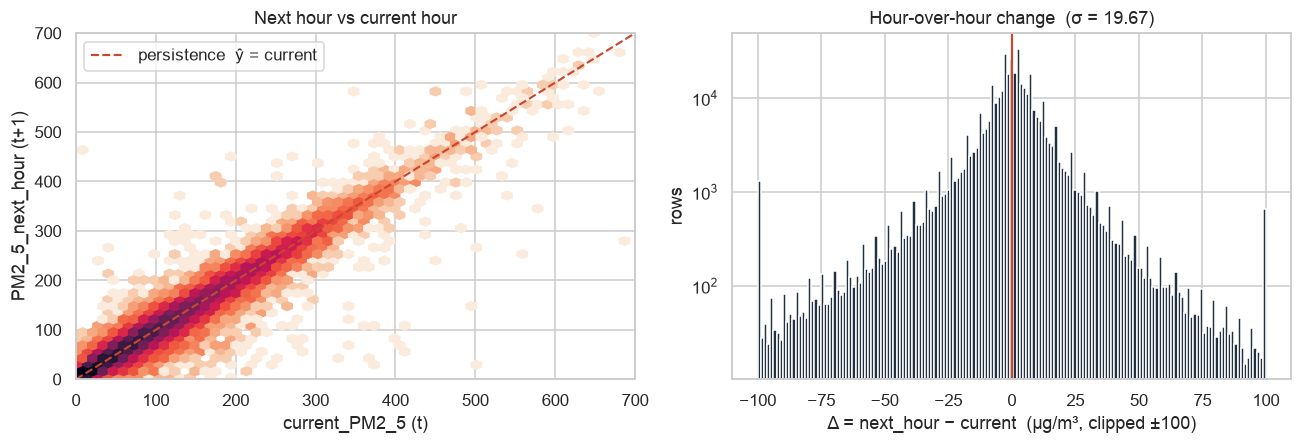

count    358488.00
mean          0.11
std          19.67
min        -628.00
1%          -61.00
5%          -25.00
25%          -5.00
50%           0.00
75%           6.00
95%          23.00
99%          49.00
max         853.00


In [4]:
delta = train[TARGET] - train[ANCHOR]
train["delta"] = delta

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sample = train.dropna(subset=[ANCHOR, TARGET]).sample(40_000, random_state=0)
axes[0].hexbin(sample[ANCHOR], sample[TARGET], gridsize=60, bins="log", cmap=SEQ, mincnt=1)
lim = [0, 700]
axes[0].plot(lim, lim, color=ACCENT, lw=1.4, ls="--", label="persistence  ŷ = current")
axes[0].set(xlim=lim, ylim=lim, xlabel="current_PM2_5 (t)", ylabel="PM2_5_next_hour (t+1)",
            title="Next hour vs current hour")
axes[0].legend(loc="upper left", frameon=True)

d = delta.dropna()
axes[1].hist(d.clip(-100, 100), bins=161, color=INK)
axes[1].axvline(0, color=ACCENT, lw=1.4)
axes[1].set(xlabel="Δ = next_hour − current  (µg/m³, clipped ±100)", ylabel="rows",
            title=f"Hour-over-hour change  (σ = {d.std():.2f})")
axes[1].set_yscale("log")

save(fig, "03_target_vs_anchor")
plt.show()

print(d.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2).to_string())

### How to read the left chart — "next hour vs current hour"

Each hexagon is a bucket of hours at some station. The horizontal position is the reading
**now**; the vertical position is the reading **an hour later**. Darker hexagons hold more
hours. The dashed red line is the rule "next hour = this hour" — that is persistence, the
guess that nothing changes.

Almost everything sits on that line. That is the whole message: **if you simply guessed
"same as now", you would be close nearly every time.** The cloud does fan out at the top
right — when the air is already dirty, it swings by larger absolute amounts.

### How to read the right chart — "how wrong is that guess?"

Take the "no change" guess and subtract it from the truth:

$$\Delta = \text{next hour} - \text{now}$$

This histogram shows what is left over — the **mistakes persistence makes**. Reading it:

- The bar at 0 is the tallest, by a lot. Most hours, the reading barely moves.
- Half of all hours move by less than about ±5 µg/m³ (that is the 25%–75% range in the
  table above).
- **The vertical axis is a log scale.** A bar one tenth the height of another means ten times
  fewer hours, not slightly fewer. Without the log scale everything except the central spike
  would be flat against the floor and invisible.
- **The tall bars at exactly −100 and +100 are not real.** They are the clipping we applied to
  keep the middle readable: every change beyond ±100 is stacked onto the edge. The true range
  runs from −628 to +853.

### What the summary numbers are telling you

| number | plain meaning |
|---|---|
| `mean = 0.11` | Guessing "no change" is **not biased**. It is not systematically too high or too low — it is wrong in both directions about equally. |
| `std = 19.67` | This is *exactly* the persistence RMSE from the baseline table. That is not a coincidence: when your average error is ≈ 0, RMSE is just the spread of the errors. **The width of this histogram is the score you have to beat.** |
| `min = −628`, `max = +853` | A handful of hours where the air changed catastrophically fast. |

### Why this matters — the actual takeaway

RMSE **squares** every error before averaging. So one hour that is off by 200 costs the same
as **1,600** hours that are off by 5. ($200^2 / 5^2 = 1{,}600$.)

Look at the histogram again with that in mind. The tall narrow middle — the ordinary, quiet
hours — is already nearly solved by persistence, and there is almost nothing left to win
there. **All of the remaining room for improvement sits in those low, flat tails.**

That flips the intuition about the task. It is not really "predict PM2.5". It is
**"predict the rare hours when PM2.5 lurches"**. A model that is slightly better on ordinary
hours but misses the swings will score *worse* than persistence, even though its average
error looks better. This is why the rest of the notebook keeps returning to the tails.

## 4. Where does the RMSE damage actually come from?

RMSE is a sum of *squared* errors, so a handful of large misses can outweigh tens of
thousands of small ones. Let's quantify that concentration instead of assuming it.

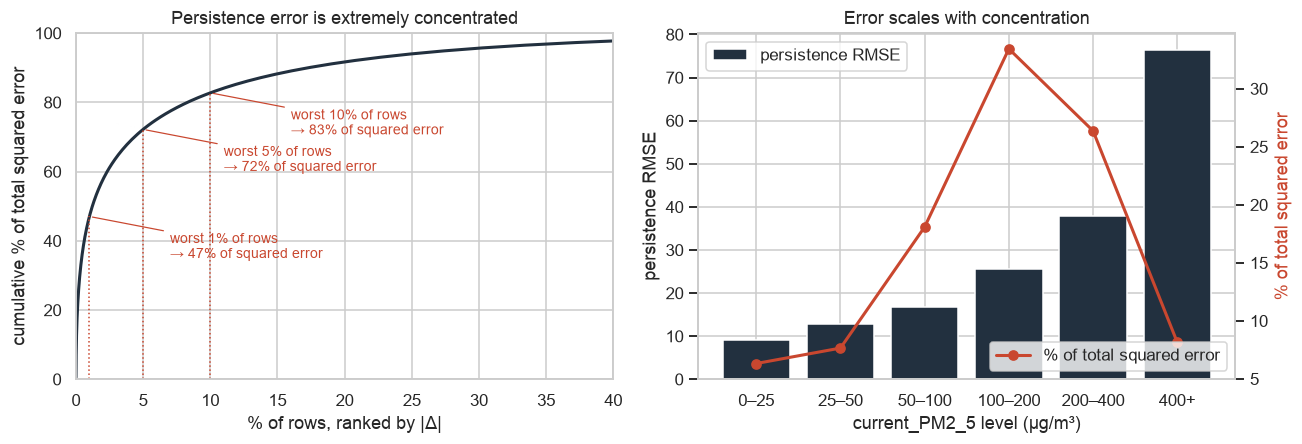

,rows,rmse,se_share
bucket,,,
0–25,104443.0,9.16,6.32
25–50,65416.0,12.74,7.65
50–100,89813.0,16.71,18.09
100–200,71384.0,25.49,33.43
200–400,25503.0,37.87,26.37
400+,1929.0,76.49,8.14


In [5]:
sq = (delta.dropna() ** 2).sort_values(ascending=False)
cum = sq.cumsum() / sq.sum()
frac_rows = np.arange(1, len(sq) + 1) / len(sq)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(frac_rows * 100, cum.to_numpy() * 100, color=INK, lw=2)
for pct in (1, 5, 10):
    y = cum.to_numpy()[int(pct / 100 * len(sq)) - 1] * 100
    axes[0].plot([pct, pct], [0, y], color=ACCENT, lw=1, ls=":")
    axes[0].annotate(f"worst {pct}% of rows\n→ {y:.0f}% of squared error",
                     (pct, y), xytext=(pct + 6, y - 12), color=ACCENT, fontsize=9,
                     arrowprops=dict(arrowstyle="-", color=ACCENT, lw=0.8))
axes[0].set(xlim=(0, 40), ylim=(0, 100), xlabel="% of rows, ranked by |Δ|",
            ylabel="cumulative % of total squared error",
            title="Persistence error is extremely concentrated")

buckets = pd.cut(train[ANCHOR], [0, 25, 50, 100, 200, 400, 1000],
                 labels=["0–25", "25–50", "50–100", "100–200", "200–400", "400+"])
by_level = train.assign(bucket=buckets).groupby("bucket", observed=True).apply(
    lambda g: pd.Series({
        "rows": len(g),
        "rmse": np.sqrt(np.nanmean(g["delta"] ** 2)),
        "se_share": np.nansum(g["delta"] ** 2),
    }),
    include_groups=False,
)
by_level["se_share"] = 100 * by_level["se_share"] / by_level["se_share"].sum()

ax2 = axes[1]
ax2.bar(by_level.index.astype(str), by_level["rmse"], color=INK, label="persistence RMSE")
ax2.set(xlabel="current_PM2_5 level (µg/m³)", ylabel="persistence RMSE",
        title="Error scales with concentration")
ax3 = ax2.twinx()
ax3.plot(by_level.index.astype(str), by_level["se_share"], color=ACCENT, marker="o", lw=2,
         label="% of total squared error")
ax3.set_ylabel("% of total squared error", color=ACCENT)
ax3.grid(False)
ax2.legend(loc="upper left")
ax3.legend(loc="lower right")

save(fig, "04_error_concentration")
plt.show()

by_level.round(2)

**Implication for modelling.** The error is not spread evenly; it is concentrated in a small
minority of high-concentration, fast-moving hours. Two consequences:

1. Optimising plain MSE on all rows is *correct* for the metric, but it means the loss is
   effectively driven by the polluted tail. Validation slices should report that tail
   separately, or improvements there will be invisible in the average.
2. Any transform that compresses the tail (log-target, for example) optimises a different
   objective than the leaderboard. If you use one, you must verify on the untransformed
   RMSE — it will often lose.

## 5. Missingness

Missingness is not noise here — instrument dropouts cluster, and the pattern differs between
train and test. Gradient-boosted trees handle NaN natively, so the question is whether
missingness is *informative*, not how to fill it.

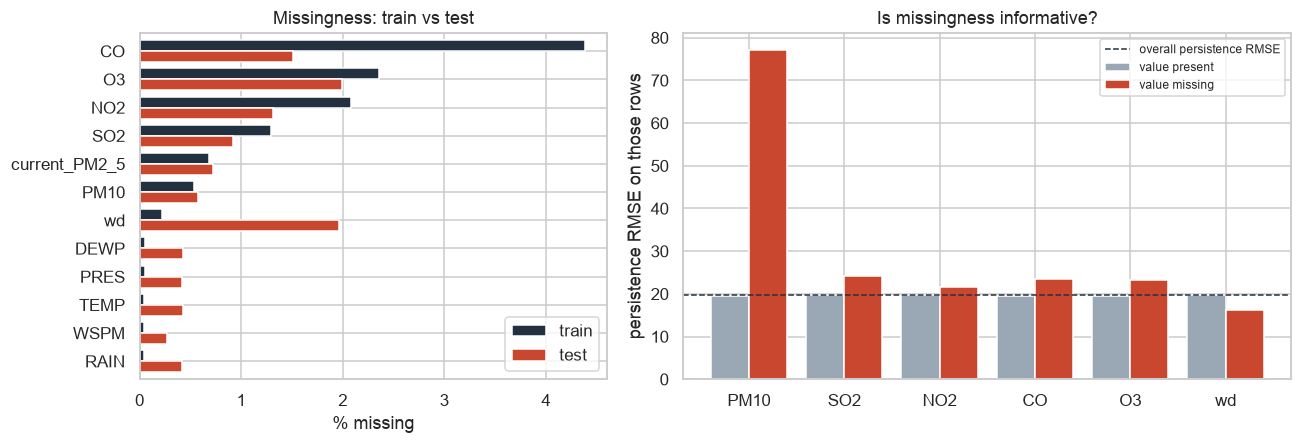

,rmse_present,rmse_missing,n_missing
column,,,
PM10,19.59,77.22,1922
SO2,19.62,24.21,4663
NO2,19.64,21.52,7521
CO,19.50,23.37,15832
O3,19.59,23.24,8499
wd,19.68,16.32,793


In [6]:
cols = POLLUTANTS + METEO + ["wd"]
miss = pd.DataFrame({
    "train": train[cols].isna().mean() * 100,
    "test": test[cols].isna().mean() * 100,
}).sort_values("train", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), width_ratios=[1, 1.3])

miss.plot.barh(ax=axes[0], color=[INK, ACCENT], width=0.78)
axes[0].set(xlabel="% missing", title="Missingness: train vs test")
axes[0].invert_yaxis()

# Is a missing pollutant associated with a different error? Compare persistence RMSE.
rows = []
for c in POLLUTANTS[1:] + ["wd"]:
    m = train[c].isna()
    rows.append({
        "column": c,
        "rmse_present": np.sqrt(np.nanmean(train.loc[~m, "delta"] ** 2)),
        "rmse_missing": np.sqrt(np.nanmean(train.loc[m, "delta"] ** 2)),
        "n_missing": int(m.sum()),
    })
informative = pd.DataFrame(rows).set_index("column")

x = np.arange(len(informative))
axes[1].bar(x - 0.2, informative["rmse_present"], 0.4, color=MUTED, label="value present")
axes[1].bar(x + 0.2, informative["rmse_missing"], 0.4, color=ACCENT, label="value missing")
axes[1].set_xticks(x, informative.index)
axes[1].axhline(19.67, color=INK, ls="--", lw=1, label="overall persistence RMSE")
axes[1].set(ylabel="persistence RMSE on those rows",
            title="Is missingness informative?")
axes[1].legend(fontsize=8)

save(fig, "05_missingness")
plt.show()

informative.round(2)

`wd` (wind direction) is the one to watch: **9× more common as a blank in test than in
train** (1.97% vs 0.22%). Treat blank `wd` as its own category — mapping it to the modal
direction would inject a systematic lie into 2% of test rows. Note also that rows with a
missing pollutant reading carry a visibly different persistence RMSE, which is evidence for
adding explicit `*_is_missing` indicators rather than silently imputing.

## 6. Temporal structure

Three periodicities to check: hour of day, month of year, and day of week. For each, the
question is asked twice — once of the **level** (which persistence already captures) and once
of the **change** (which is what we must predict).

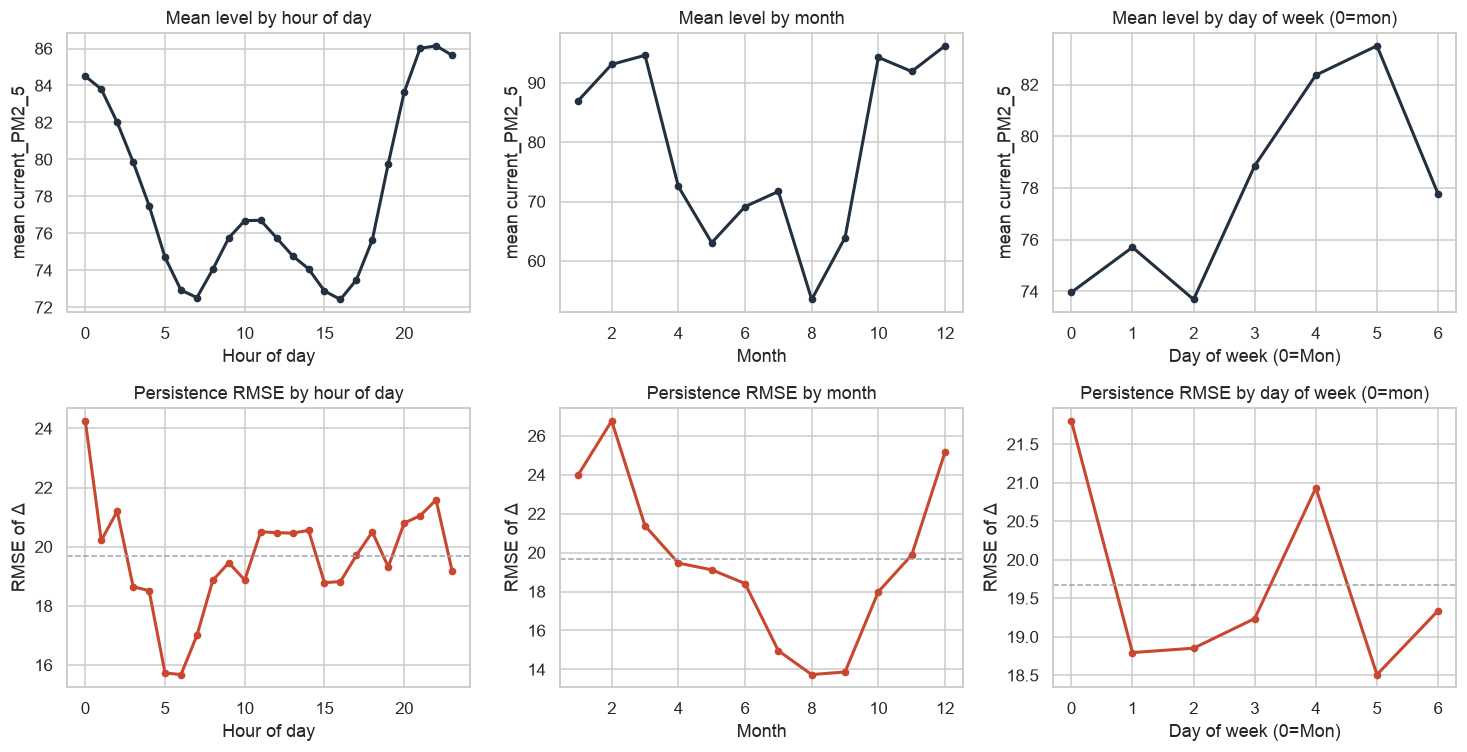

In [7]:
train["dow"] = train["observation_timestamp"].dt.dayofweek

fig, axes = plt.subplots(2, 3, figsize=(13.5, 7))
specs = [("hour", "Hour of day"), ("month", "Month"), ("dow", "Day of week (0=Mon)")]

for j, (col, label) in enumerate(specs):
    g = train.groupby(col)
    lvl = g[ANCHOR].mean()
    axes[0, j].plot(lvl.index, lvl.to_numpy(), color=INK, marker="o", ms=4, lw=2)
    axes[0, j].set(title=f"Mean level by {label.lower()}", xlabel=label, ylabel="mean current_PM2_5")

    volatility = g["delta"].apply(lambda s: np.sqrt(np.nanmean(s**2)))
    axes[1, j].plot(volatility.index, volatility.to_numpy(), color=ACCENT, marker="o", ms=4, lw=2)
    axes[1, j].axhline(19.67, color=MUTED, ls="--", lw=1)
    axes[1, j].set(title=f"Persistence RMSE by {label.lower()}", xlabel=label, ylabel="RMSE of Δ")

save(fig, "06_seasonality")
plt.show()

The top row shows the familiar pollution climatology: a winter maximum, a summer minimum, and
a mild diurnal cycle with an overnight/early-morning peak. **Persistence already gets all of
this for free** — it is embedded in `current_PM2_5`.

The bottom row is the informative one. Persistence RMSE is *not* flat across hours or months:
it rises in the winter months and through the afternoon/evening. Those are the periods where
a model has room to improve, and — inconveniently — they are exactly the periods the test set
over-represents.

Encode these cyclically (`sin`/`cos` of hour and day-of-year) rather than as raw integers, so
that hour 23 and hour 0 are neighbours.

## 7. The train/test shift

The test period is **September–February only**: heating season, and materially more polluted
than the training average. This is the single largest threat to a naively-validated model.

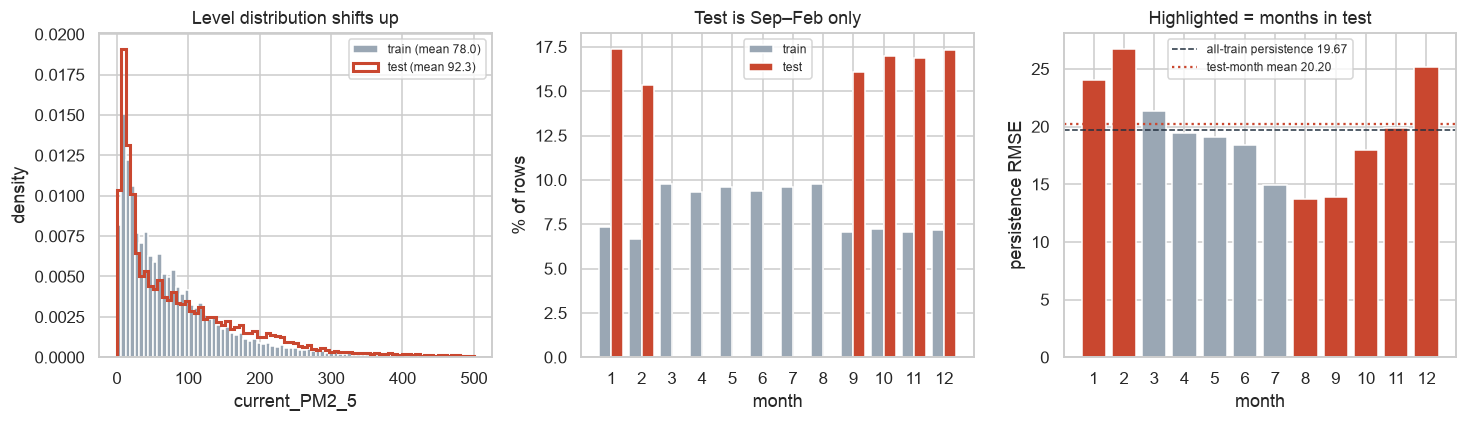

train current_PM2_5 mean 77.99   test 92.32
blank wd:  train 0.22%   test 1.97%


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))

bins = np.linspace(0, 500, 80)
axes[0].hist(train[ANCHOR].dropna(), bins=bins, density=True, color=MUTED, label=f"train (mean {train[ANCHOR].mean():.1f})")
axes[0].hist(test[ANCHOR].dropna(), bins=bins, density=True, histtype="step", lw=2, color=ACCENT,
             label=f"test (mean {test[ANCHOR].mean():.1f})")
axes[0].set(xlabel="current_PM2_5", ylabel="density", title="Level distribution shifts up")
axes[0].legend(fontsize=8)

tr_m = train.month.value_counts(normalize=True).sort_index() * 100
te_m = test.month.value_counts(normalize=True).sort_index().reindex(range(1, 13), fill_value=0) * 100
w = 0.4
axes[1].bar(tr_m.index - w / 2, tr_m.to_numpy(), w, color=MUTED, label="train")
axes[1].bar(te_m.index + w / 2, te_m.to_numpy(), w, color=ACCENT, label="test")
axes[1].set(xlabel="month", ylabel="% of rows", title="Test is Sep–Feb only", xticks=range(1, 13))
axes[1].legend(fontsize=8)

# Monthly persistence RMSE in train, restricted to the months the test set actually contains.
test_months = sorted(test.month.unique())
by_month = train.groupby("month")["delta"].apply(lambda s: np.sqrt(np.nanmean(s**2)))
colors = [ACCENT if m in test_months else MUTED for m in by_month.index]
axes[2].bar(by_month.index, by_month.to_numpy(), color=colors)
axes[2].axhline(19.67, color=INK, ls="--", lw=1, label="all-train persistence 19.67")
heating = by_month.loc[[m for m in by_month.index if m in test_months]].mean()
axes[2].axhline(heating, color=ACCENT, ls=":", lw=1.5, label=f"test-month mean {heating:.2f}")
axes[2].set(xlabel="month", ylabel="persistence RMSE", title="Highlighted = months in test",
            xticks=range(1, 13))
axes[2].legend(fontsize=8)

save(fig, "07_train_test_shift")
plt.show()

print(f"train {ANCHOR} mean {train[ANCHOR].mean():.2f}   test {test[ANCHOR].mean():.2f}")
print(f"blank wd:  train {train.wd.isna().mean()*100:.2f}%   test {test.wd.isna().mean()*100:.2f}%")

**Why this decides your validation design.** A CV score averaged over all twelve months is
measuring a different problem than the leaderboard. The headline number should be the mean
RMSE over **heating-season folds** only — that is what `src/pm25/validation.py` is for.

It also explains why raw `year` is a trap: test years (2016–17) sit outside the training
range, and a tree splitting on `year` cannot extrapolate. Use relative or cyclical encodings.

## 8. Cross-station structure

Twelve stations in one urban network. If a pollution front sweeps across the city, a
neighbouring station's reading at hour `t` is legitimate information about *our* station at
`t+1` — no future data involved.

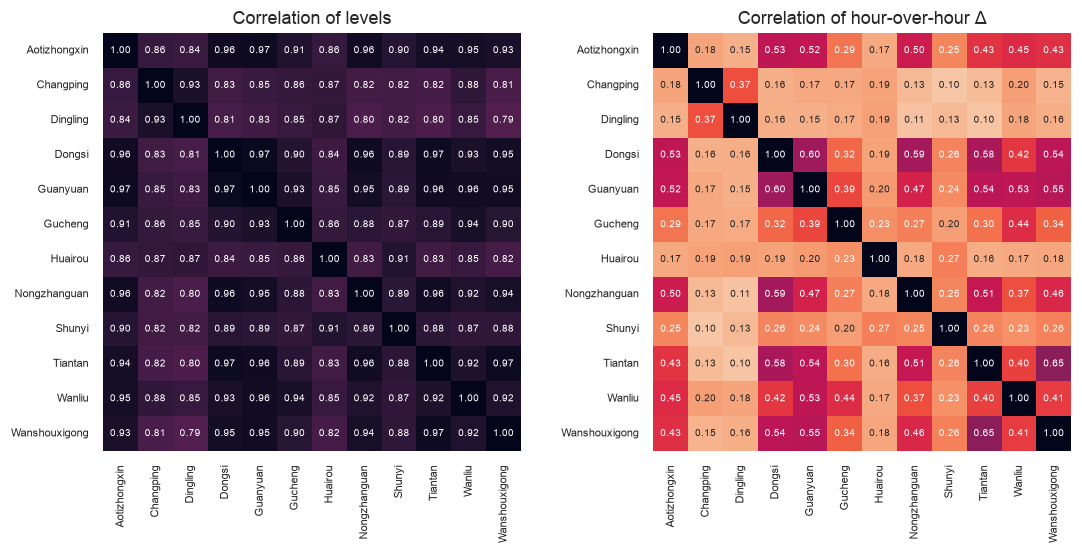

mean off-diagonal correlation of Δ across stations: 0.302


In [9]:
levels = train.pivot_table(index="observation_timestamp", columns="station", values=ANCHOR)
changes = train.pivot_table(index="observation_timestamp", columns="station", values="delta")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, mat, title in [(axes[0], levels, "Correlation of levels"),
                       (axes[1], changes, "Correlation of hour-over-hour Δ")]:
    sns.heatmap(mat.corr(), ax=ax, cmap="rocket_r", vmin=0, vmax=1, square=True,
                annot=True, fmt=".2f", annot_kws={"size": 6.5}, cbar=False)
    ax.set(title=title, xlabel="", ylabel="")
    ax.tick_params(labelsize=7.5)

save(fig, "08_cross_station")
plt.show()

off = changes.corr().to_numpy()[np.triu_indices(changes.shape[1], k=1)]
print(f"mean off-diagonal correlation of Δ across stations: {off.mean():.3f}")

Levels are correlated at 0.7–0.9 — unsurprising, all twelve stations share a regional airshed.
The **changes** are the interesting panel. Their correlation is much weaker (mean off-diagonal
**0.30**) but clearly non-zero: when PM2.5 is rising at one station it tends to be rising at
others in the same hour. Weak-but-real is exactly the kind of signal worth having, given how
little of Δ anything explains.

That is a directly usable feature family: the network-wide mean and spread at hour `t`, and
each station's deviation from it. Build them as same-hour aggregates — they need no shift at
all, so they cannot leak.

## 9. Lag structure — how far back is worth looking?

How much of the change at `t+1` is predictable from the recent past? Autocorrelation of the
**change** series answers that. All lags are strictly positive (backward-looking).

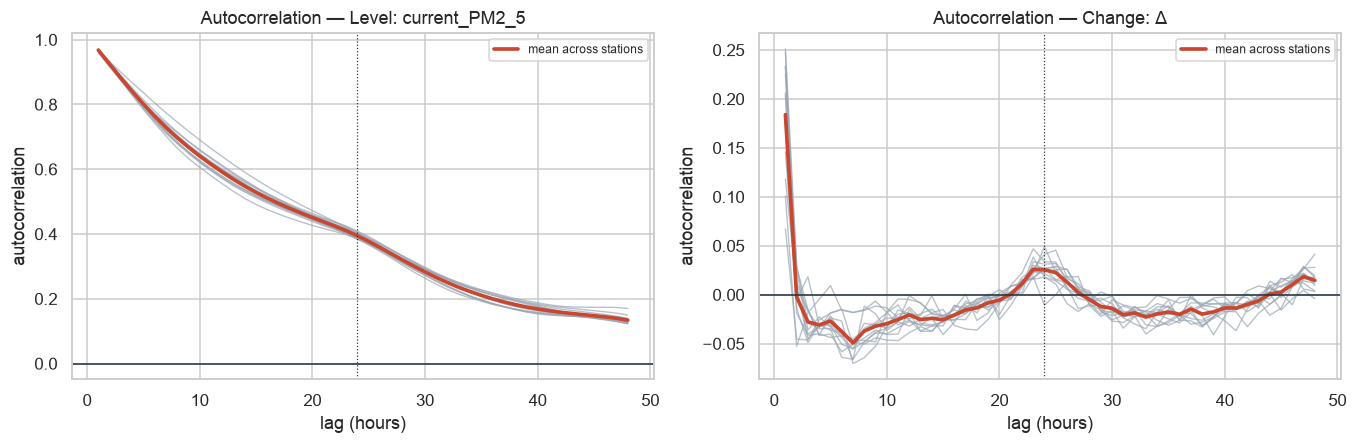

mean Δ autocorrelation at lags 1,2,3,24: [np.float64(0.184), np.float64(-0.002), np.float64(-0.028), np.float64(0.025)]


In [10]:
lags = list(range(1, 49))
acf_level = pd.DataFrame({s: [levels[s].autocorr(k) for k in lags] for s in levels.columns}, index=lags)
acf_delta = pd.DataFrame({s: [changes[s].autocorr(k) for k in lags] for s in changes.columns}, index=lags)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
for ax, acf, title in [(axes[0], acf_level, "Level: current_PM2_5"),
                       (axes[1], acf_delta, "Change: Δ")]:
    for s in acf.columns:
        ax.plot(acf.index, acf[s], color=MUTED, lw=0.9, alpha=0.7)
    ax.plot(acf.index, acf.mean(axis=1), color=ACCENT, lw=2.4, label="mean across stations")
    ax.axhline(0, color=INK, lw=1)
    ax.axvline(24, color=INK, lw=0.8, ls=":")
    ax.set(xlabel="lag (hours)", ylabel="autocorrelation", title=f"Autocorrelation — {title}")
    ax.legend(fontsize=8)

save(fig, "09_autocorrelation")
plt.show()

print("mean Δ autocorrelation at lags 1,2,3,24:",
      [round(acf_delta.mean(axis=1)[k], 3) for k in (1, 2, 3, 24)])

The level series is enormously persistent (lag-1 ≈ 0.97) with a visible daily echo at lag 24.
The change series is a different story: lag-1 autocorrelation of Δ is **0.18** — real momentum,
rises tend to follow rises — but it collapses to ≈ 0.00 by lag 2 and stays there, with no daily
echo (lag 24 ≈ 0.03).

So do **not** expect deep lags of Δ itself to pay. The exploitable memory is one hour of
momentum, plus whatever the *level* history says about the current regime.

Practically: lags of 1, 2, 3, 6, 12 and 24 hours on `current_PM2_5`, plus backward rolling
means and — importantly — backward rolling *standard deviations*, since recent volatility
should predict the size of the next move. Build these on a **complete hourly grid**; there are
2,466 places in train where consecutive surviving rows are more than an hour apart, and a
naive `.shift(1)` there would silently mean "the previous surviving row".

## 10. Meteorology

Wind, humidity and pressure drive dispersion and accumulation. We look at their relationship
to the *change*, not the level.

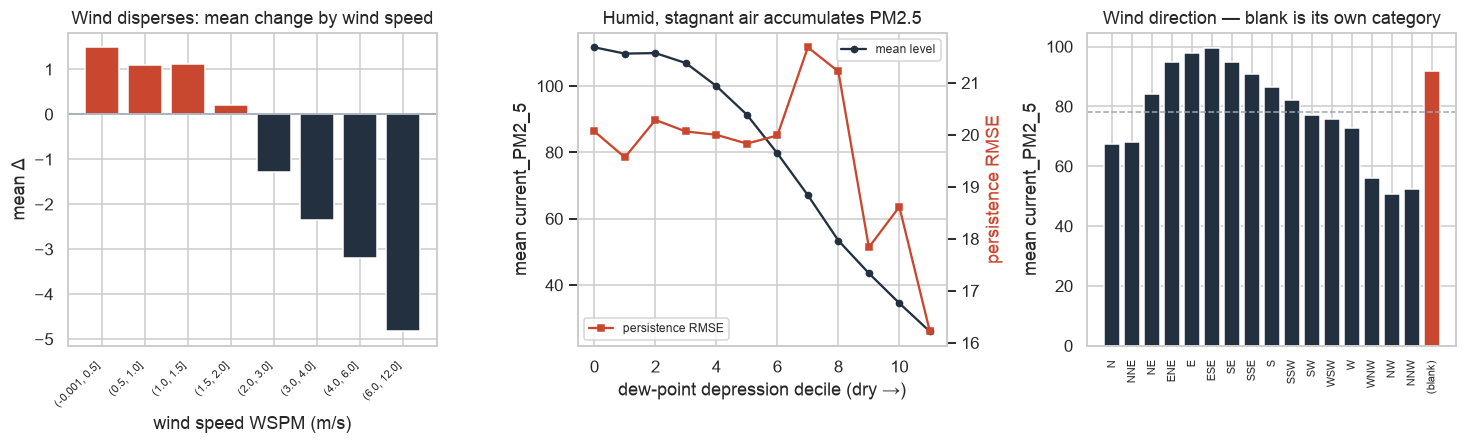

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

# Wind speed vs signed change — dispersion should push concentrations down.
wbin = pd.cut(train.WSPM, [0, 0.5, 1, 1.5, 2, 3, 4, 6, 12], include_lowest=True)
w_stats = train.groupby(wbin, observed=True).agg(mean_delta=("delta", "mean"),
                                                 level=(ANCHOR, "mean"), n=("delta", "size"))
axes[0].bar(range(len(w_stats)), w_stats["mean_delta"], color=np.where(w_stats["mean_delta"] < 0, INK, ACCENT))
axes[0].axhline(0, color=MUTED, lw=1)
axes[0].set_xticks(range(len(w_stats)), [str(i) for i in w_stats.index], rotation=45, ha="right", fontsize=7.5)
axes[0].set(xlabel="wind speed WSPM (m/s)", ylabel="mean Δ", title="Wind disperses: mean change by wind speed")

# Dew-point depression (TEMP − DEWP) is a humidity proxy; low values = damp, stagnant air.
train["dewp_depression"] = train["TEMP"] - train["DEWP"]
dbin = pd.qcut(train["dewp_depression"], 12, duplicates="drop")
d_stats = train.groupby(dbin, observed=True).agg(level=(ANCHOR, "mean"), rmse=("delta", lambda s: np.sqrt(np.nanmean(s**2))))
axes[1].plot(range(len(d_stats)), d_stats["level"], color=INK, marker="o", ms=4, label="mean level")
axes[1].set(xlabel="dew-point depression decile (dry →)", ylabel="mean current_PM2_5",
            title="Humid, stagnant air accumulates PM2.5")
ax1b = axes[1].twinx()
ax1b.plot(range(len(d_stats)), d_stats["rmse"], color=ACCENT, marker="s", ms=4, label="persistence RMSE")
ax1b.set_ylabel("persistence RMSE", color=ACCENT)
ax1b.grid(False)
axes[1].legend(loc="upper right", fontsize=8)
ax1b.legend(loc="lower left", fontsize=8)

# Wind direction, blank category retained.
ORDER = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE",
         "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"]
wd = train["wd"].fillna("(blank)")
wd_stats = train.assign(wd_f=wd).groupby("wd_f", observed=True)[ANCHOR].mean()
wd_stats = wd_stats.reindex(ORDER + ["(blank)"])
colors = [ACCENT if k == "(blank)" else INK for k in wd_stats.index]
axes[2].bar(range(len(wd_stats)), wd_stats.to_numpy(), color=colors)
axes[2].set_xticks(range(len(wd_stats)), wd_stats.index, rotation=90, fontsize=7)
axes[2].axhline(train[ANCHOR].mean(), color=MUTED, ls="--", lw=1)
axes[2].set(ylabel="mean current_PM2_5", title="Wind direction — blank is its own category")

save(fig, "10_meteorology")
plt.show()

Three readable signals:

- **Wind speed.** Above roughly 2 m/s the mean change turns negative — wind mechanically
  disperses particulate. This is one of the few variables that predicts the *sign* of Δ.
- **Humidity.** Mean level falls steeply and monotonically as the air dries — from ~112 µg/m³
  in the dampest decile to ~25 in the driest. Persistence RMSE broadly follows, but *not*
  monotonically: it peaks in the middle deciles rather than the dampest. The hardest hours are
  transitional air, not simply stagnant air.
- **Wind direction.** Easterly and north-easterly flow (E, ESE, ENE, NE) carries the dirtiest
  air, ~95–100 µg/m³; north-westerly (NW, WNW, NNW) is cleanest at ~50. And the `(blank)` bar
  sits at ~92 — far above the 78 average, and nowhere near the modal direction's value. That
  is direct evidence it must stay its own category rather than being imputed away.

## 11. Spike events — the hours that decide the score

Section 4 showed the squared error concentrates in a few percent of rows. Let's look at those
rows directly: what does a rapid-onset event look like, and how badly does persistence fail?

rows with Δ ≥ 30: 3.04%  |  persistence RMSE on them 63.0 vs 16.5 elsewhere  |  they carry 31.4% of all squared error


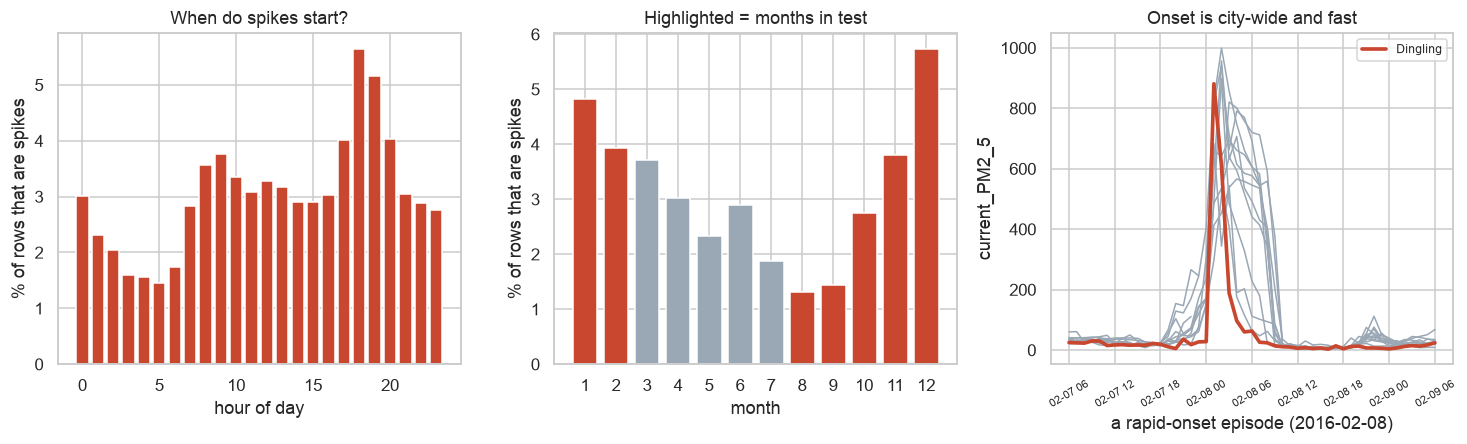

In [12]:
SPIKE = 30  # µg/m³ rise within one hour
train["is_spike"] = train["delta"] >= SPIKE

spike_rate = train["is_spike"].mean() * 100
rmse_spike = np.sqrt(np.nanmean(train.loc[train.is_spike, "delta"] ** 2))
rmse_calm = np.sqrt(np.nanmean(train.loc[~train.is_spike, "delta"] ** 2))
se_share = 100 * np.nansum(train.loc[train.is_spike, "delta"] ** 2) / np.nansum(train["delta"] ** 2)

print(f"rows with Δ ≥ {SPIKE}: {spike_rate:.2f}%  |  persistence RMSE on them {rmse_spike:.1f} "
      f"vs {rmse_calm:.1f} elsewhere  |  they carry {se_share:.1f}% of all squared error")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

hr = train.groupby("hour")["is_spike"].mean() * 100
axes[0].bar(hr.index, hr.to_numpy(), color=ACCENT)
axes[0].set(xlabel="hour of day", ylabel="% of rows that are spikes", title="When do spikes start?")

mo = train.groupby("month")["is_spike"].mean() * 100
axes[1].bar(mo.index, mo.to_numpy(), color=[ACCENT if m in test_months else MUTED for m in mo.index])
axes[1].set(xlabel="month", ylabel="% of rows that are spikes", xticks=range(1, 13),
            title="Highlighted = months in test")

# One concrete episode, drawn from the worst 24h in the record.
worst_day = train.loc[train["delta"].idxmax(), "observation_timestamp"].normalize()
win = train[(train.observation_timestamp >= worst_day - pd.Timedelta(hours=18))
            & (train.observation_timestamp <= worst_day + pd.Timedelta(hours=30))]
for s, g in win.groupby("station"):
    axes[2].plot(g.observation_timestamp, g[ANCHOR], color=MUTED, lw=1)
focus = win[win.station == train.loc[train["delta"].idxmax(), "station"]]
axes[2].plot(focus.observation_timestamp, focus[ANCHOR], color=ACCENT, lw=2.4, label=focus.station.iloc[0])
axes[2].set(xlabel=f"a rapid-onset episode ({worst_day:%Y-%m-%d})", ylabel="current_PM2_5",
            title="Onset is city-wide and fast")
axes[2].tick_params(axis="x", rotation=30, labelsize=7.5)
axes[2].legend(fontsize=8)

save(fig, "11_spikes")
plt.show()

Spikes are rare, seasonally clustered into exactly the months the test set covers, and they
carry a wildly disproportionate share of the squared error. The episode plot shows why the
cross-station features from section 8 matter: onset is a **city-wide** event, so neighbouring
stations rising in the same hour is a genuine early signal.

This is the concrete meaning of the rule in `CLAUDE.md`: a model that is slightly better on
calm hours and worse on rapid-onset events is a worse model, even if its average looks fine.
Always break validation results out by spike/calm.

## 12. Feature-signal scan

A quick ranked look at which raw columns carry linear signal about Δ. This is a screening
device, not a verdict — trees will find interactions this misses.

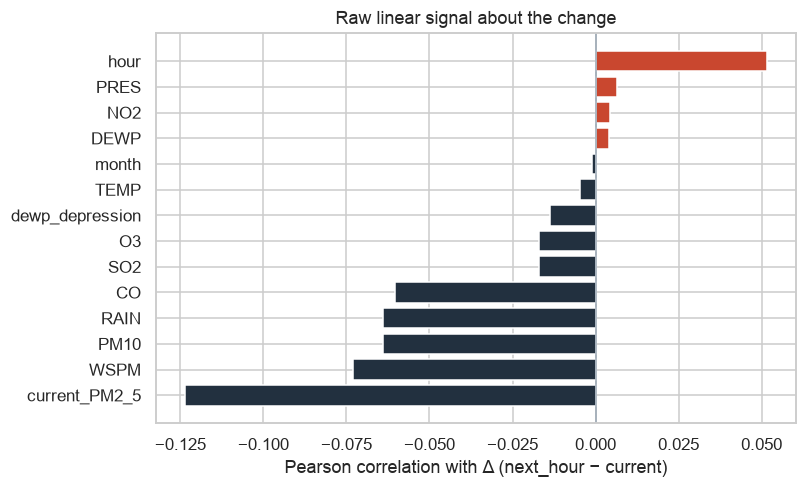

,corr_with_delta
current_PM2_5,-0.1237
WSPM,-0.0731
PM10,-0.0641
RAIN,-0.0640
CO,-0.0603
SO2,-0.0170
O3,-0.0169
dewp_depression,-0.0136
TEMP,-0.0046
month,-0.0009


In [13]:
num = POLLUTANTS + METEO + ["dewp_depression", "hour", "month"]
corr = train[num + ["delta"]].corr(numeric_only=True)["delta"].drop("delta").sort_values()

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.barh(corr.index, corr.to_numpy(), color=np.where(corr < 0, INK, ACCENT))
ax.axvline(0, color=MUTED, lw=1)
ax.set(xlabel="Pearson correlation with Δ (next_hour − current)",
       title="Raw linear signal about the change")
save(fig, "12_signal_scan")
plt.show()

corr.round(4).to_frame("corr_with_delta")

Every correlation is small — which is exactly what you should expect, and is the honest
statement of how hard this problem is. Persistence explains almost everything; the remaining
signal about Δ is weak, non-linear, and concentrated in rare regimes. That is a job for
gradient-boosted trees on well-constructed lag, rolling and cross-station features, not for a
linear model on raw columns.

## 13. What this EDA says to do next

**Validation.** Expanding-window folds on timestamps, headline = mean RMSE over
heating-season folds, every result quoted as a delta against that fold's persistence score.
Never a random split (§2), never the public leaderboard.

**Features, in rough order of expected value:**

1. Backward lags of `current_PM2_5` at 1, 2, 3, 6, 12, 24 h, built on a complete hourly grid
   (§9) — the 2,466 gaps make this non-optional.
2. Backward rolling mean **and standard deviation** over 3/6/24 h. Recent volatility predicts
   the size of the next move (§9, §11).
3. Same-hour cross-station aggregates: network mean, spread, and this station's deviation
   from it (§8). No shift needed, so no leakage risk.
4. Cyclical hour and day-of-year; explicitly **not** raw `year` (§6, §7).
5. Wind speed and direction with `(blank)` as a real category, plus dew-point depression
   (§10).
6. `*_is_missing` indicators for the pollutant columns (§5).

**Reporting.** Break every result out by fold, and separately by spike vs calm hours (§11). A
single averaged RMSE hides precisely the failure mode that costs the most.

**Guard rails.** Run `make audit` before generating any submission. If a validation RMSE ever
comes in below ~8, assume leakage and go hunting before celebrating.

---

Figures are in `reports/figures/`. Once a finding here becomes load-bearing, graduate it out
of this notebook into `src/pm25/` — per `CLAUDE.md`, a notebook must not become the source of
truth for a feature.